# Single Neuron Linear Regression Model
In this notebook, I will implement a single neuron model alongside the gradient descent algorithm, in order to display Linear Regression and Logistic Regression. We will be using the breast cancer dataset

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("../../DataSets/Advertising.csv")

In [9]:
df.iloc[:100]

,Index,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
95,96,163.3,31.6,52.9,16.9
96,97,197.6,3.5,5.9,11.7
97,98,184.9,21.0,22.0,15.5
98,99,289.7,42.3,51.2,25.4


In [10]:
scaler = MinMaxScaler()
X = scaler.fit_transform(df[["TV", "radio", "newspaper"]])
y = df.sales.values

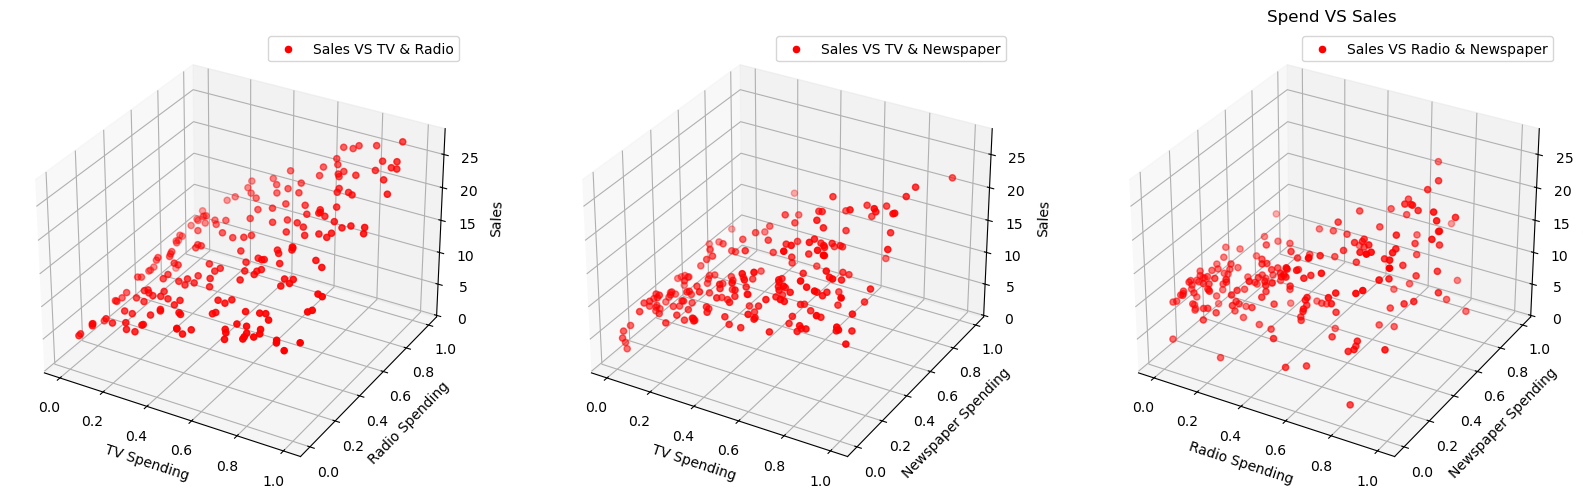

In [11]:
fig = plt.figure(figsize=(20,20))

attr_lst = ["TV", "Radio", "Newspaper"]
k = 0
for k, (i, j) in enumerate([(0,1), (0,2), (1,2)], start=1):
    ax = fig.add_subplot(1, 3, k, projection="3d")
    ax.scatter(X[:, i], X[:, j], y, c="red", label="Sales VS " + attr_lst[i] +" & "+ attr_lst[j])
    ax.set_xlabel(attr_lst[i] + " Spending")
    ax.set_ylabel(attr_lst[j] + " Spending")
    ax.set_zlabel("Sales")
    ax.legend()
    k += 1

#ax1 = fig.add_subpplot(112, projection="3d")
#ax.scatter(X[:, 0], X[:, 0], y, c="blue", label="Sales VS TV & Newspaper")
#ax.set_xlabel("TV Spending")
#ax.set_ylabel("Newspaper Spending")
#ax.set_zlabel("Sales")

#ax.legend()
plt.title("Spend VS Sales")
plt.show()

In [29]:
class SingleNeuron(object):
    """
    A class used to represent a Single Neuron

    Attributes
    ----------
    inputs : array
        an array of inputs to the perceptron
    outputs : array
        an array of expected outputs from the perceptron
    alpha : float
        the learning rate
    epochs : int
        the number of epochs to train

    Methods
    -------
    train()
        trains the perceptron for self.epoch iterations, to produce self.outputs from self.inputs.

    train_err_limit(self, percent_err, max_epochs=None)
        trains the perceptron until it reaches a certain percent_error rate or until max_epochs are reached.

    update_weights()
        updates the weights of the perceptron(self.w_) once using self.inputs and comparing with self.outputs.

    net_input(inputs):
        calculates the net input to the perceptron, by multiplying a given input with the weights and adding the bias.
    
    predict():
        calculates the output the perceptron produces for a given input.
    
    """
    
    def __init__(self, inputs, outputs, activation_function, alpha = 0.005, epochs = 100):
        if not(isinstance(epochs, int)):
            raise TypeError("epochs must be an integer.")
        if epochs < 1:
            raise ValueError("Epochs must be less than 1")
        if not isinstance(alpha, float):
            raise TypeError("aplha must be a float")
        if not (0 < alpha <= 1):
            raise ValueError("alpha must be between 0 and 1")
        if not isinstance(inputs, np.ndarray) or not isinstance(outputs, np.ndarray):
            raise TypeError("inputs and outputs must be NumPy arrays")
        if inputs.shape[0] != outputs.shape[0]:
            raise ValueError("inputs and outputs must have the same number of samples")
        if len(outputs.shape) != 1:
            raise ValueError("outputs must be a 1D array")
        
        self.activation_function = activation_function 
        self.alpha = alpha
        self.epochs = epochs
        self.inputs = inputs
        self.outputs = outputs
        self.w_ = np.random.rand(1+inputs.shape[1])
        self.errors_ = []
    
    def train(self):
        N = self.inputs.shape[0]

        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(self.inputs, self.outputs):
                """
                error = self.predict(xi) - target
                update_val = self.alpha * error
                self.w_[:-1] -= update_val*xi
                self.w_[-1] -= update_val
                errors += 0.5 * (update_val ** 2)
                """
                
                error = self.predict(xi) - target
                self.w_[:-1] -= self.alpha * error * xi
                self.w_[-1] -= self.alpha * error
                errors += 0.5 * (error ** 2)

            
            self.errors_.append(errors/N)
        return
    def predict(self, X):
        preactivation = np.dot(X, self.w_[:-1]) + self.w_[-1]
        return self.activation_function(preactivation)

In [30]:

def linear_activation(z):
    return z
node = SingleNeuron(X, y,  linear_activation)
node.train()

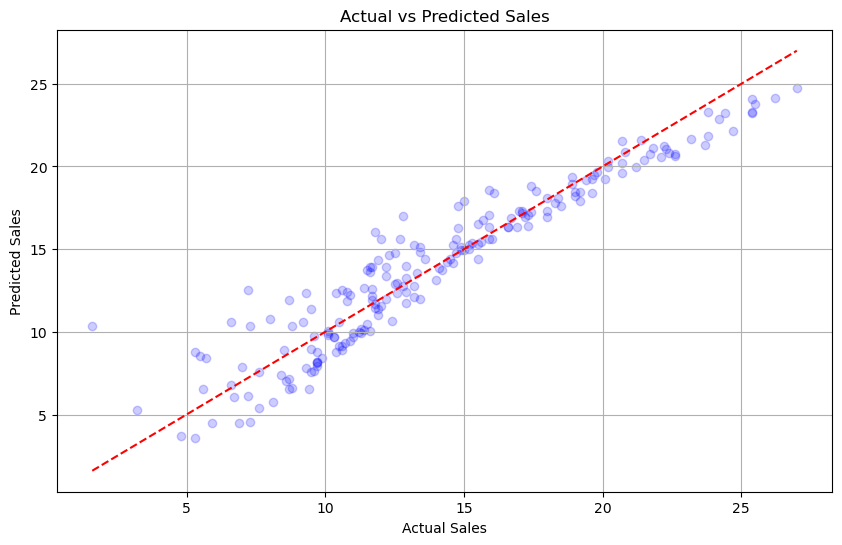

In [31]:
y_pred = node.predict(X)

# You can add this to one of the 3D subplots, or plot actual vs predicted:
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, c='blue', alpha=0.2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.plot([min(y), max(y)], [min(y), max(y)], 'r--')  # Line y = x
plt.grid(True)
plt.show()